# Projeto de Machine Learning — APS1: EDA

**Dataset:** New York City Airbnb Open Data  
**Tema:** regressão — preparação para previsão do preço (`price`) de anúncios de Airbnb em Nova York  
**Grupo:** Maria Eduarda Oliveira Galdino e Tomaz Santos Almeida  
**Data de entrega:** 14/09  
**Fonte dos dados:** https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data

## Objetivo

Realizar uma análise exploratória completa do dataset de anúncios de Airbnb na cidade de Nova York, entendendo sua estrutura, qualidade, distribuições e relações entre variáveis. O resultado prepara o dataset para a etapa posterior de modelagem de regressão (APS2), cujo alvo será `price`. Nesta APS1 não há treinamento de modelos.

# 1.1 Descrição das features

| Feature | Descrição |
|---|---|
| `id` | Identificador único do anúncio. |
| `name` | Nome/título do anúncio. |
| `host_id` | Identificador do anfitrião. |
| `host_name` | Nome do anfitrião. |
| `neighbourhood_group` | Grupo de bairros (borough). |
| `neighbourhood` | Bairro específico. |
| `latitude` | Latitude do imóvel. |
| `longitude` | Longitude do imóvel. |
| `room_type` | Tipo de acomodação. |
| `price` | Preço anunciado por noite, em USD; será o target da APS2. |
| `minimum_nights` | Número mínimo de noites exigidas. |
| `number_of_reviews` | Número total de avaliações. |
| `last_review` | Data da avaliação mais recente. |
| `reviews_per_month` | Número médio de avaliações por mês. |
| `calculated_host_listings_count` | Quantidade de anúncios do mesmo anfitrião. |
| `availability_365` | Número de dias disponíveis no ano. |

In [1]:
from pathlib import Path

# Procura o CSV nos locais mais comuns; se necessário, usa o KaggleHub.
candidates = [
    Path("AB_NYC_2019.csv"),
    Path("/content/AB_NYC_2019.csv"),
    Path("/kaggle/input/new-york-city-airbnb-open-data/AB_NYC_2019.csv"),
]
csv_path = next((p for p in candidates if p.exists()), None)

if csv_path is None:
    try:
        import kagglehub
        folder = Path(kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data"))
        csv_path = folder / "AB_NYC_2019.csv"
    except Exception:
        csv_path = "https://raw.githubusercontent.com/MainakRepositor/Datasets/master/AB_NYC_2019.csv"

print("Fonte utilizada:", csv_path)

Fonte utilizada: AB_NYC_2019.csv


In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 100,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})
pd.set_option("display.max_columns", None)

df = pd.read_csv(csv_path)
print(f"Dimensão do dataset: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

Dimensão do dataset: 48,895 linhas × 16 colunas


In [3]:
display(df.head())

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


# 1.2 Verificar o número de instâncias e features.

Pelo `df.shape`, temos 48895 instâncias e 16 features (contando com id).

In [4]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

# 1.3 Identificar tipos de dados (numéricos e categóricos)

**Numéricos:** `id`, `host_id`, `latitude`, `longitude`, `price`, `minimum_nights`, `number_of_reviews`, `reviews_per_month`, `calculated_host_listings_count` e `availability_365`.

`id` e `host_id`, embora armazenados como números, são identificadores e não devem ser interpretados como grandezas em estatísticas ou correlações.

**Categóricos/textuais:** `name`, `host_name`, `neighbourhood_group`, `neighbourhood` e `room_type`. `last_review` está armazenada como texto, mas conceitualmente é uma data e exigiria tratamento específico.

In [5]:
# Resumo dos tipos sem repetir df.info()
tipos = df.dtypes.astype(str).to_frame("dtype")
tipos["tipo conceitual"] = [
    "identificador", "texto", "identificador", "texto",
    "categórica", "categórica", "numérica", "numérica",
    "categórica", "numérica (target)", "numérica", "numérica",
    "data armazenada como texto", "numérica", "numérica", "numérica"
]
display(tipos)

,dtype,tipo conceitual
id,int64,identificador
name,object,texto
host_id,int64,identificador
host_name,object,texto
neighbourhood_group,object,categórica
neighbourhood,object,categórica
latitude,float64,numérica
longitude,float64,numérica
room_type,object,categórica
price,int64,numérica (target)


# 1.4 Detectar valores ausentes e inconsistências

Há 10.052 valores ausentes em `last_review` e o mesmo número em `reviews_per_month`, além de 21 em `host_name` e 16 em `name`. A coincidência entre `last_review` e `reviews_per_month` indica anúncios sem avaliações, e não necessariamente erro de coleta.

Também foram encontrados 11 anúncios com `price = 0`, tratados como erro de cadastro do alvo. Há 14 anúncios com `minimum_nights > 365`, incluindo máximo de 1.250 noites. Esses valores são **potencialmente inconsistentes**, mas o campo pode representar regras de locação de longo prazo; por isso serão mantidos nesta etapa e comprimidos por `log1p`. Na APS2, recomenda-se uma análise de sensibilidade com e sem esses registros.

Não há IDs duplicados e todas as coordenadas estão dentro da área geográfica esperada de Nova York.

In [6]:
# Valores ausentes por coluna
missing = pd.DataFrame({
    "ausentes": df.isna().sum(),
    "%": (100 * df.isna().mean()).round(2)
}).sort_values("ausentes", ascending=False)
display(missing)

,ausentes,%
last_review,10052,20.56
reviews_per_month,10052,20.56
host_name,21,0.04
name,16,0.03
neighbourhood_group,0,0.00
neighbourhood,0,0.00
id,0,0.00
host_id,0,0.00
longitude,0,0.00
latitude,0,0.00


In [7]:
# Inconsistências detectadas
# 1. Preços iguais a zero (Airbnb não é gratuito, indício de erro de cadastro)
print("Anúncios com price = 0:", (df['price'] == 0).sum())
display(df[df['price'] == 0][['name', 'room_type', 'price']].head())

# 2. Estadia mínima exigida acima de 1 ano
print("Anúncios com minimum_nights > 365:", (df['minimum_nights'] > 365).sum())
display(df[df['minimum_nights'] > 365][['name', 'minimum_nights']].head())

# 3. IDs duplicados (esperado: 0, já que id deveria ser único)
print("IDs duplicados:", df['id'].duplicated().sum())

# 4. Coordenadas fora da área geográfica de Nova York
lat_fora = ((df['latitude'] < 40.49) | (df['latitude'] > 40.92)).sum()
long_fora = ((df['longitude'] < -74.25) | (df['longitude'] > -73.70)).sum()
print("Latitudes fora do esperado:", lat_fora)
print("Longitudes fora do esperado:", long_fora)

Anúncios com price = 0: 11
Anúncios com minimum_nights > 365: 14
IDs duplicados: 0
Latitudes fora do esperado: 0
Longitudes fora do esperado: 0


,name,room_type,price
23161,"Huge Brooklyn Brownstone Living, Close to it all.",Private room,0
25433,★Hostel Style Room | Ideal Traveling Buddies★,Private room,0
25634,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",Private room,0
25753,"Sunny, Quiet Room in Greenpoint",Private room,0
25778,Modern apartment in the heart of Williamsburg,Entire home/apt,0


,name,minimum_nights
1305,800sqft apartment with huge terrace,370
2854,NaN,1000
5767,Prime W. Village location 1 bdrm,1250
7355,Beautiful Fully Furnished 1 bed/bth,500
8014,Wonderful Large 1 bedroom,500


# 1.5 Verificar se há desbalanceamento de classes

Como o problema é de regressão, não existe uma classe-alvo para balancear. Entretanto, `neighbourhood_group` e `room_type` apresentam forte diferença de representatividade: Manhattan e Brooklyn concentram a maior parte dos anúncios, enquanto Shared room e Staten Island são minoritários.

Isso não exige reamostragem automática, mas torna as conclusões dos grupos menores menos estáveis e deve ser considerado na interpretação e na futura avaliação do modelo.

In [8]:
# Desbalanceamento das variáveis categóricas
print("room_type:")
display(df['room_type'].value_counts(normalize=True))

print("\nneighbourhood_group:")
display(df['neighbourhood_group'].value_counts(normalize=True))

room_type:

neighbourhood_group:


room_type
Entire home/apt    0.519665
Private room       0.456611
Shared room        0.023724
Name: proportion, dtype: float64

neighbourhood_group
Manhattan        0.443011
Brooklyn         0.411167
Queens           0.115881
Bronx            0.022313
Staten Island    0.007629
Name: proportion, dtype: float64

In [9]:
# last_review representa datas, não categorias de domínio
last_review_dates = pd.to_datetime(df["last_review"], errors="coerce")
print("Datas distintas em last_review:", df["last_review"].nunique())
print("Período observado:", last_review_dates.min().date(), "a", last_review_dates.max().date())

Datas distintas em last_review: 1764
Período observado: 2011-03-28 a 2019-07-08


# 1.6 Separação dos dados em treino e teste

A separação é realizada antes de imputação, encoding, normalização ou PCA. Assim, todas as transformações que aprendem parâmetros serão ajustadas somente no treino, evitando vazamento de dados (*data leakage*). Como o alvo é contínuo e assimétrico, usamos decis de preço apenas para estratificar a divisão e preservar a distribuição da cauda.

In [10]:
# Regra de validade do alvo: uma diária comercial deve ter price > 0.
df = df.loc[df["price"] > 0].copy()

X = df.drop(columns=["price"])
y = df["price"]
price_decile = pd.qcut(y, q=10, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=price_decile
)

print("Shape do treino:", X_train.shape)
print("Shape do teste:", X_test.shape)
print("Mediana do target — treino/teste:", y_train.median(), y_test.median())

Shape do treino: (39107, 15)
Shape do teste: (9777, 15)
Mediana do target — treino/teste: 106.0 106.0


# 2.1 Estatísticas descritivas das variáveis numéricas

Os identificadores `id` e `host_id` são excluídos desta análise. O preço apresenta forte assimetria à direita: média de **US$ 152,76**, mediana de **US$ 106**, desvio-padrão de **US$ 240,17** e máximo de **US$ 10.000**. Portanto, a mediana representa melhor um anúncio típico.

O mesmo padrão aparece em `minimum_nights` — média de **7,03** e mediana de **3** — e em `number_of_reviews` — média de **23,27** e mediana de **5**. Essas diferenças justificam o uso de medidas robustas na interpretação e de transformação logarítmica nas variáveis de cauda longa.

In [11]:
numericas = df.select_dtypes(include=["number"]).drop(columns=["id", "host_id"])
estatisticas = pd.DataFrame({
    "média": numericas.mean(),
    "mediana": numericas.median(),
    "desvio padrão": numericas.std(),
    "mínimo": numericas.min(),
    "máximo": numericas.max(),
    "assimetria": numericas.skew(),
})
display(estatisticas.style.format("{:.2f}"))

,média,mediana,desvio padrão,mínimo,máximo,assimetria
latitude,40.73,40.72,0.05,40.50,40.91,0.24
longitude,-73.95,-73.96,0.05,-74.24,-73.71,1.28
price,152.76,106.00,240.17,10.00,10000.00,19.12
minimum_nights,7.03,3.00,20.51,1.00,1250.00,21.83
number_of_reviews,23.27,5.00,44.55,0.00,629.00,3.69
reviews_per_month,1.37,0.72,1.68,0.01,58.50,3.13
calculated_host_listings_count,7.14,1.00,32.96,1.00,327.00,7.93
availability_365,112.78,45.00,131.63,0.00,365.00,0.76


# 2.2 Histogramas, boxplot e violino para variáveis numéricas (máximo 3)

Os limites dos eixos são aplicados apenas para tornar as distribuições centrais legíveis. **Nenhum registro adicional é removido** por causa desses limites; as caudas completas continuam presentes nos dados e nas estatísticas.

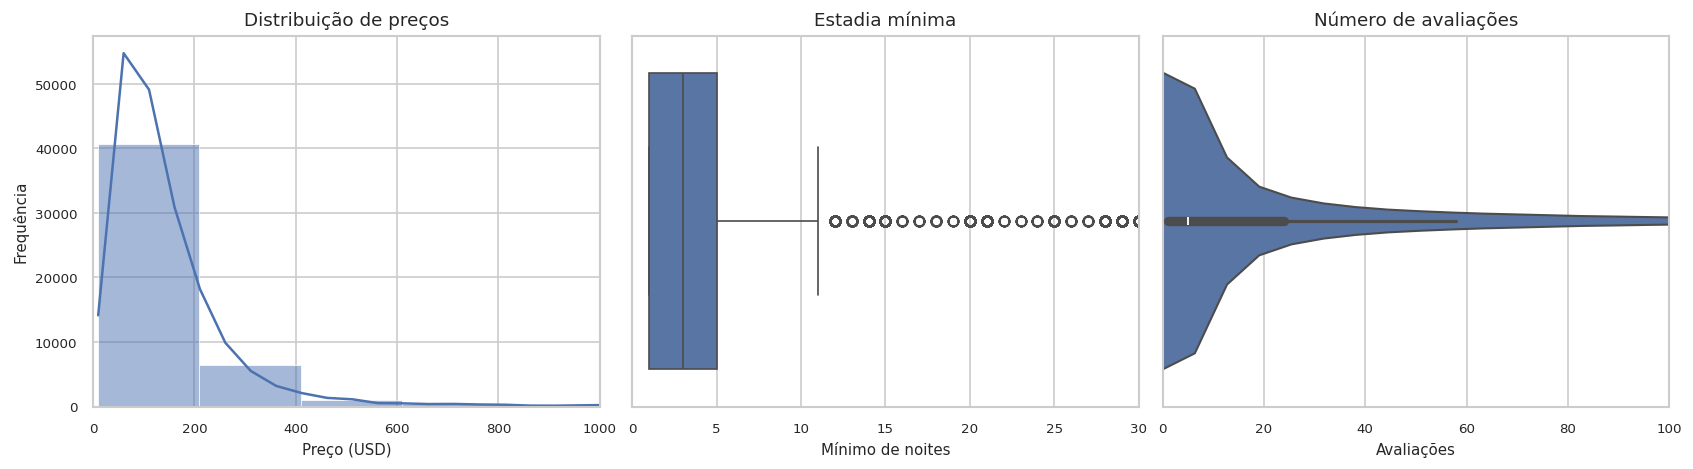

In [12]:
# Três visualizações numéricas em um painel compacto
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)

sns.histplot(df["price"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribuição de preços")
axes[0].set(xlabel="Preço (USD)", ylabel="Frequência", xlim=(0, 1000))

sns.boxplot(x=df["minimum_nights"], ax=axes[1])
axes[1].set_title("Estadia mínima")
axes[1].set(xlabel="Mínimo de noites", xlim=(0, 30))

sns.violinplot(x=df["number_of_reviews"], ax=axes[2], cut=0)
axes[2].set_title("Número de avaliações")
axes[2].set(xlabel="Avaliações", xlim=(0, 100))

plt.show()

# 2.3 Para variáveis categóricas: calcular frequências e criar gráficos de barras (máximo 3).

Resposta: as frequências mostram que Entire home/apt (52.0%) e Private room (45.7%), juntos, possuem quase toda base de anúncios em room_type, enquanto Shared room apenas 2,4%. O mesmo ocorre para neighbourhood_group (com Manhattan (44.3%) e Brooklyn (41.1%), deixando os outros bairros para trás). Isso confirma o desbalanceamento. Isso significa que estatísticas calculadas para os grupos minoritários, como Staten Island (0.8%) ou Shared room (2.4%), têm menor confiabilidade estatística por se basearem em amostras muito menores, o que deve ser considerado ao interpretar médias e ao aplicar técnicas de encoding no pré-processamento.

In [13]:
# FREQUÊNCIAS
# room_type
print(df['room_type'].value_counts())
print(df['room_type'].value_counts(normalize=True))

# neighbourhood_group
print(df['neighbourhood_group'].value_counts())
print(df['neighbourhood_group'].value_counts(normalize=True))

# neighbourhood (top 10)
print(df['neighbourhood'].value_counts().head(10))

room_type
Entire home/apt    25407
Private room       22319
Shared room         1158
Name: count, dtype: int64
room_type
Entire home/apt    0.519741
Private room       0.456571
Shared room        0.023689
Name: proportion, dtype: float64
neighbourhood_group
Manhattan        21660
Brooklyn         20095
Queens            5666
Bronx             1090
Staten Island      373
Name: count, dtype: int64
neighbourhood_group
Manhattan        0.443090
Brooklyn         0.411075
Queens           0.115907
Bronx            0.022298
Staten Island    0.007630
Name: proportion, dtype: float64
neighbourhood
Williamsburg          3919
Bedford-Stuyvesant    3710
Harlem                2658
Bushwick              2462
Upper West Side       1971
Hell's Kitchen        1958
East Village          1853
Upper East Side       1798
Crown Heights         1564
Midtown               1545
Name: count, dtype: int64


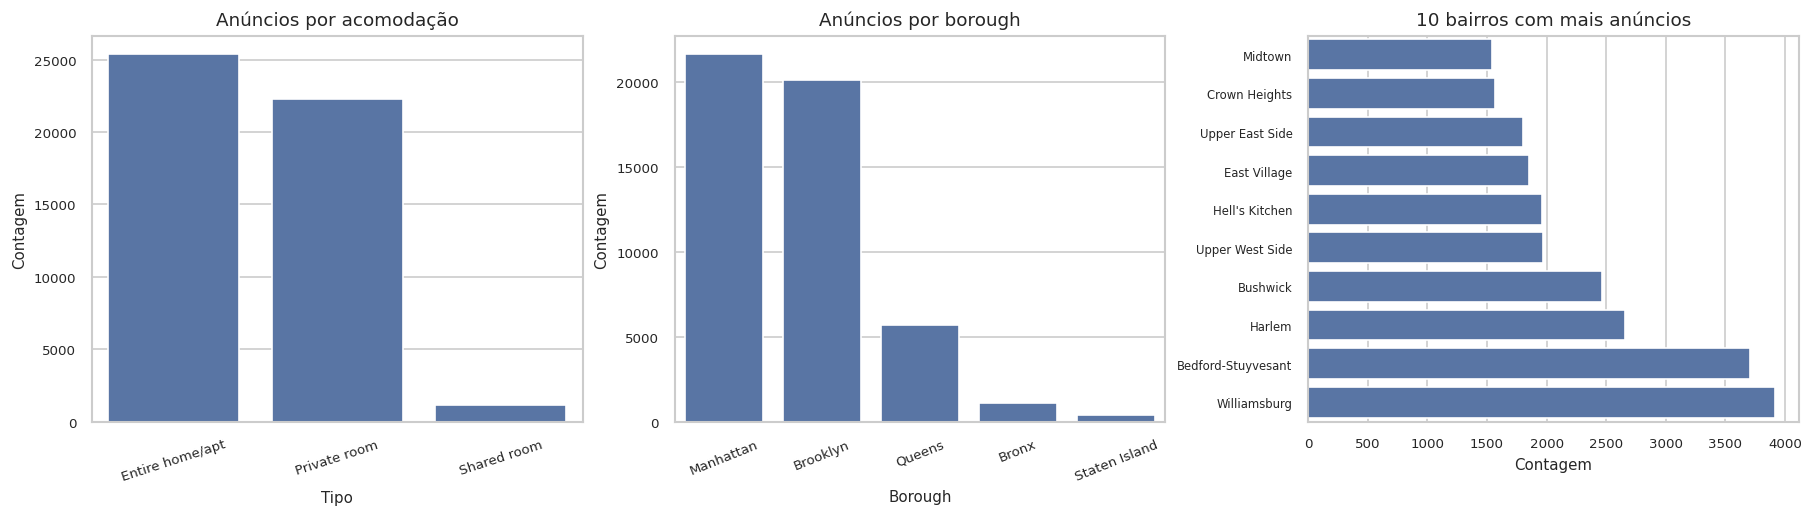

In [14]:
# Três gráficos categóricos em um painel compacto
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)

room_order = df["room_type"].value_counts().index
sns.countplot(x="room_type", data=df, order=room_order, ax=axes[0])
axes[0].set_title("Anúncios por acomodação")
axes[0].set(xlabel="Tipo", ylabel="Contagem")
axes[0].tick_params(axis="x", rotation=18)

group_order = df["neighbourhood_group"].value_counts().index
sns.countplot(x="neighbourhood_group", data=df, order=group_order, ax=axes[1])
axes[1].set_title("Anúncios por borough")
axes[1].set(xlabel="Borough", ylabel="Contagem")
axes[1].tick_params(axis="x", rotation=22)

top10 = df["neighbourhood"].value_counts().head(10).sort_values()
sns.barplot(x=top10.values, y=top10.index, ax=axes[2])
axes[2].set_title("10 bairros com mais anúncios")
axes[2].set(xlabel="Contagem", ylabel="")
axes[2].tick_params(axis="y", labelsize=7)

plt.show()

# 3.1 Correlações e scatter plots (máximo 3 visualizações)

Todas as correlações lineares com `price` são fracas; a maior é com `longitude`, aproximadamente **0,15**. Isso reforça que nenhuma variável numérica isolada explica bem o preço e que localização, acomodação e demais características provavelmente interagem de forma não linear.

A relação numérica mais evidente ocorre entre `number_of_reviews` e `reviews_per_month` (aproximadamente 0,55), pois ambas representam atividade de avaliações. `calculated_host_listings_count` e `availability_365` apresentam associação positiva de aproximadamente 0,23, possivelmente relacionada a anfitriões profissionais.

Para obedecer à interpretação mais conservadora do limite, são apresentadas exatamente três visualizações: uma matriz de correlação e dois scatter plots. No gráfico de longitude × preço, o eixo do preço vai até o P99 apenas para legibilidade; nenhuma linha é removida. Correlação não implica causalidade.

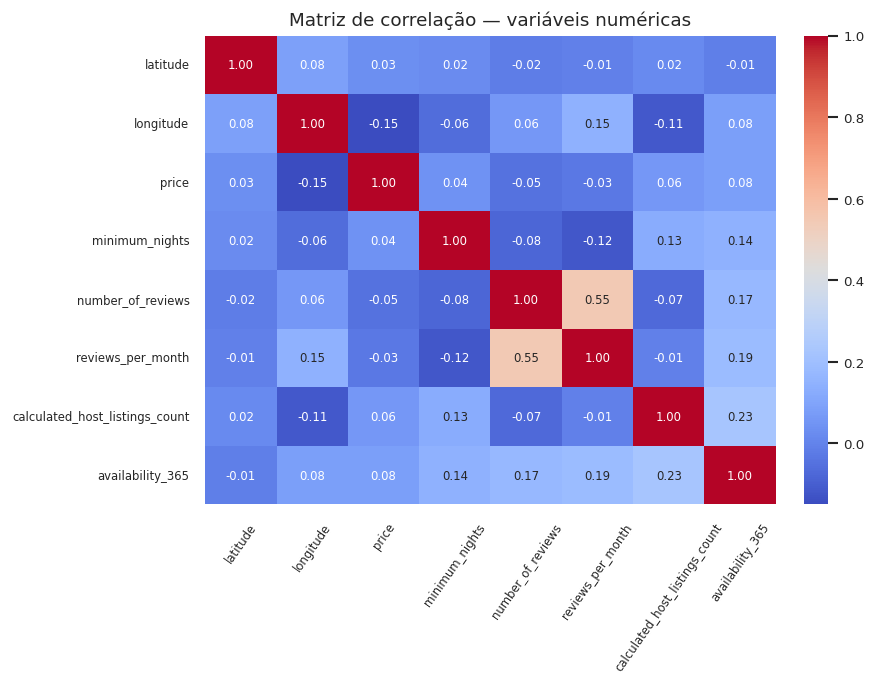

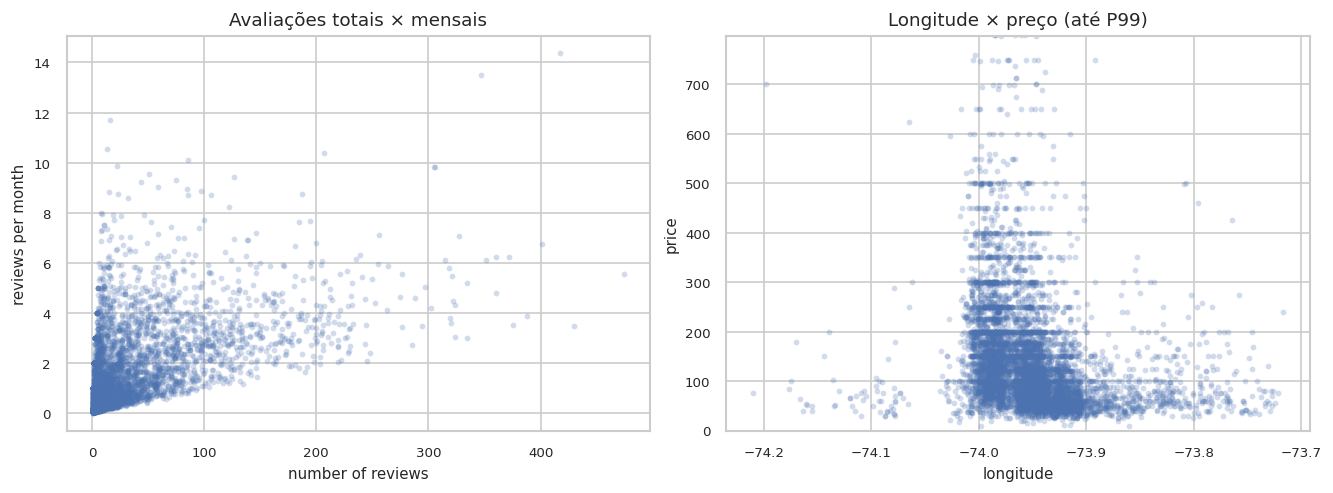

In [15]:
# Correlação entre variáveis numéricas
numericas = df.select_dtypes(include=["int64", "float64"]).drop(columns=["id", "host_id"])

# 1ª visualização: heatmap
fig, ax = plt.subplots(figsize=(7.2, 5.6), constrained_layout=True)
sns.heatmap(numericas.corr(), annot=True, cmap="coolwarm", fmt=".2f",
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Matriz de correlação — variáveis numéricas")
ax.tick_params(axis="x", rotation=55, labelsize=7)
ax.tick_params(axis="y", rotation=0, labelsize=7)
plt.show()

# Amostra somente para renderização; os coeficientes usam a base completa.
scatter_sample = df.sample(min(7000, len(df)), random_state=42)
pares = [
    ("number_of_reviews", "reviews_per_month", "Avaliações totais × mensais"),
    ("longitude", "price", "Longitude × preço (até P99)"),
]

# 2ª e 3ª visualizações, organizadas no mesmo painel.
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, (x, y, title) in zip(axes, pares):
    sns.scatterplot(data=scatter_sample, x=x, y=y, alpha=0.25, s=12,
                    linewidth=0, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(x.replace("_", " "))
    ax.set_ylabel(y.replace("_", " "))
axes[1].set_ylim(0, df["price"].quantile(0.99))
plt.show()

# 3.2 Variáveis categóricas e o target `price`

Como `price` possui assimetria de 19,12 e máximo de US$ 10.000, poucos anúncios muito caros podem distorcer médias. Por isso, os gráficos usam **mediana**, enquanto as tabelas apresentam contagem, média e mediana.

- **`room_type` × `price`:** Entire home/apt possui mediana superior, coerente com maior privacidade e espaço.
- **`neighbourhood_group` × `price`:** Manhattan apresenta a maior mediana. A associação pode refletir centralidade, demanda e características não observadas; não é um efeito causal isolado.
- **`neighbourhood` × `price`:** existe variação dentro dos boroughs. Para evitar rankings definidos por amostras muito pequenas, são considerados apenas bairros com pelo menos 20 anúncios.

Tipo de acomodação:
Borough:
Top 10 bairros por mediana (mínimo de 20 anúncios):


,n,média,mediana
room_type,,,
Entire home/apt,25407,211.81,160.00
Private room,22319,89.81,70.00
Shared room,1158,70.25,45.00


,n,média,mediana
neighbourhood_group,,,
Manhattan,21660,196.88,150.00
Brooklyn,20095,124.44,90.00
Queens,5666,99.52,75.00
Staten Island,373,114.81,75.00
Bronx,1090,87.58,65.00


,n,média,mediana
neighbourhood,,,
Tribeca,177,490.64,295.00
NoHo,78,295.72,250.00
Flatiron District,80,341.93,225.00
Midtown,1545,282.72,210.00
Financial District,744,225.49,200.00
West Village,768,267.68,200.00
Chelsea,1113,249.74,199.00
SoHo,358,287.10,199.00
Greenwich Village,392,263.41,197.50


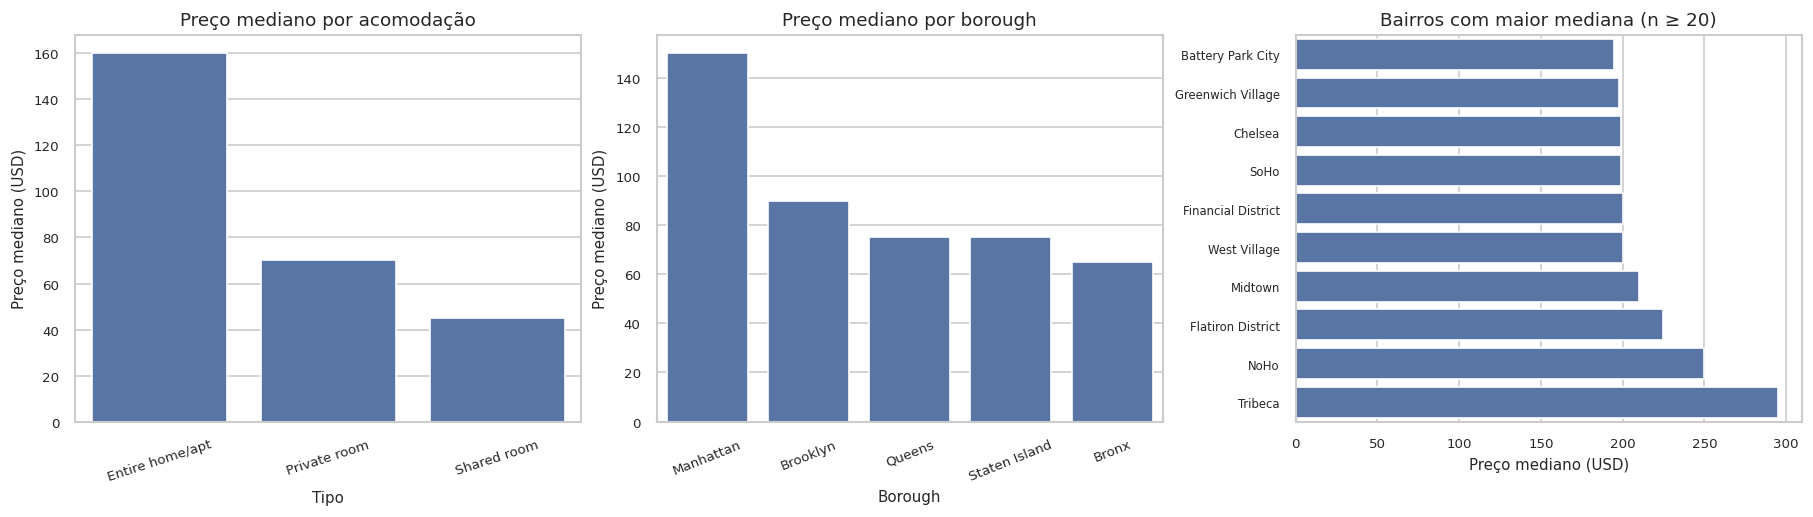

In [16]:
# Preço por categoria: mediana nos gráficos; n, média e mediana nas tabelas
room_stats = df.groupby("room_type")["price"].agg(n="size", média="mean", mediana="median")
room_stats = room_stats.sort_values("mediana", ascending=False)

group_stats = df.groupby("neighbourhood_group")["price"].agg(n="size", média="mean", mediana="median")
group_stats = group_stats.sort_values("mediana", ascending=False)

neighbourhood_stats = df.groupby("neighbourhood")["price"].agg(n="size", média="mean", mediana="median")
top10_bairros = neighbourhood_stats.query("n >= 20").nlargest(10, "mediana").sort_values("mediana")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
sns.barplot(x=room_stats.index, y=room_stats["mediana"], ax=axes[0])
axes[0].set_title("Preço mediano por acomodação")
axes[0].set(xlabel="Tipo", ylabel="Preço mediano (USD)")
axes[0].tick_params(axis="x", rotation=18)

sns.barplot(x=group_stats.index, y=group_stats["mediana"], ax=axes[1])
axes[1].set_title("Preço mediano por borough")
axes[1].set(xlabel="Borough", ylabel="Preço mediano (USD)")
axes[1].tick_params(axis="x", rotation=22)

sns.barplot(x=top10_bairros["mediana"], y=top10_bairros.index, ax=axes[2])
axes[2].set_title("Bairros com maior mediana (n ≥ 20)")
axes[2].set(xlabel="Preço mediano (USD)", ylabel="")
axes[2].tick_params(axis="y", labelsize=7)
plt.show()

print("Tipo de acomodação:")
display(room_stats.style.format({"média": "{:.2f}", "mediana": "{:.2f}"}))
print("Borough:")
display(group_stats.style.format({"média": "{:.2f}", "mediana": "{:.2f}"}))
print("Top 10 bairros por mediana (mínimo de 20 anúncios):")
display(top10_bairros.sort_values("mediana", ascending=False)
        .style.format({"média": "{:.2f}", "mediana": "{:.2f}"}))

# 3.3 Relações entre variáveis numéricas e categóricas

- **`availability_365` × `room_type`:** as distribuições diferem entre tipos de acomodação, sugerindo padrões distintos de oferta; disponibilidade, porém, não mede diretamente ocupação ou procura.
- **`minimum_nights` × `neighbourhood_group`:** as medianas são próximas, mas as caudas e dispersões variam. O eixo é limitado apenas para visualização.
- **`reviews_per_month` × `room_type`:** há forte sobreposição entre os grupos; isoladamente, essa combinação parece ter menor poder de separação.

Essas relações são descritivas e não causais.

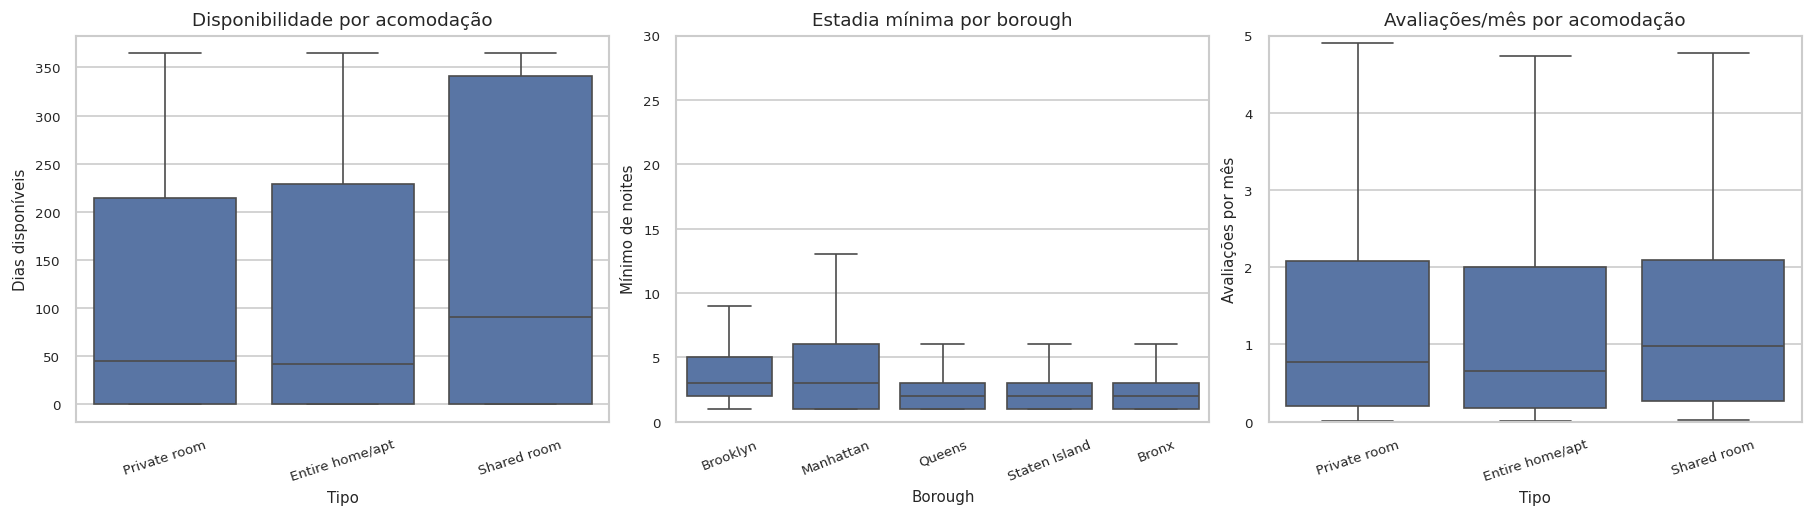

In [17]:
# Três boxplots em um painel compacto
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)

sns.boxplot(x="room_type", y="availability_365", data=df,
            showfliers=False, ax=axes[0])
axes[0].set_title("Disponibilidade por acomodação")
axes[0].set(xlabel="Tipo", ylabel="Dias disponíveis")
axes[0].tick_params(axis="x", rotation=18)

sns.boxplot(x="neighbourhood_group", y="minimum_nights", data=df,
            showfliers=False, ax=axes[1])
axes[1].set_title("Estadia mínima por borough")
axes[1].set(xlabel="Borough", ylabel="Mínimo de noites", ylim=(0, 30))
axes[1].tick_params(axis="x", rotation=22)

sns.boxplot(x="room_type", y="reviews_per_month", data=df,
            showfliers=False, ax=axes[2])
axes[2].set_title("Avaliações/mês por acomodação")
axes[2].set(xlabel="Tipo", ylabel="Avaliações por mês", ylim=(0, 5))
axes[2].tick_params(axis="x", rotation=18)

plt.show()

# 4.1 Estratégia para valores ausentes

O único valor ausente relevante entre as features selecionadas é `reviews_per_month`. Os casos coincidem com anúncios sem `last_review` e todos possuem `number_of_reviews = 0`. Por isso, essa coluna recebe imputação **zero**, que possui significado real.

As demais variáveis numéricas recebem imputação pela **mediana**, caso surjam ausências em dados futuros. `name`, `host_name` e `last_review` são descartadas por serem texto livre, identificação ou informação temporal não explorada nesta versão. `id` e `host_id` também são removidos por serem identificadores.

In [18]:
# Evidência para a estratégia de imputação
sem_review = df["reviews_per_month"].isna()
coincidem = (df.loc[sem_review, "number_of_reviews"] == 0).mean()
print("Ausentes em reviews_per_month:", sem_review.sum())
print("Percentual desses anúncios com number_of_reviews = 0:", f"{coincidem:.1%}")

missing_plan = pd.Series({
    "reviews_per_month": "imputar 0",
    "demais numéricas usadas": "imputar mediana, se necessário",
    "categóricas usadas": "imputar moda, se necessário",
    "name/host_name/last_review": "descartar nesta versão",
})
display(missing_plan.to_frame("decisão"))

Ausentes em reviews_per_month: 10051
Percentual desses anúncios com number_of_reviews = 0: 100.0%


,decisão
reviews_per_month,imputar 0
demais numéricas usadas,"imputar mediana, se necessário"
categóricas usadas,"imputar moda, se necessário"
name/host_name/last_review,descartar nesta versão


# 4.2 Estratégia para outliers

- Os 11 registros com `price = 0` foram removidos uma única vez, antes da separação, por representarem inconsistência do alvo.
- Os 14 anúncios com `minimum_nights > 365`, incluindo o máximo de 1.250, são potencialmente inconsistentes. Como podem representar contratos de longa duração, serão mantidos e comprimidos por `log1p`; na APS2, deve-se comparar o desempenho com e sem esses casos.
- Outros valores altos, porém plausíveis, não serão removidos automaticamente: excluí-los reduziria a capacidade de generalização para anúncios incomuns.
- `minimum_nights`, `number_of_reviews`, `reviews_per_month` e `calculated_host_listings_count` possuem cauda longa e recebem `log1p` antes da padronização.
- Para a futura APS2, a transformação logarítmica do target poderá ser testada dentro do pipeline do modelo. Nesta APS1, o alvo não é transformado.

In [19]:
# Quantificação de valores extremos pela regra exploratória do IQR
cols_outliers = ["price", "minimum_nights", "number_of_reviews",
                 "reviews_per_month", "calculated_host_listings_count"]
outlier_summary = []
for col in cols_outliers:
    s = df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    count = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()
    outlier_summary.append({"variável": col, "n fora de 1,5×IQR": count,
                            "%": 100 * count / len(s), "máximo": s.max()})
display(pd.DataFrame(outlier_summary).set_index("variável").style.format("{:.2f}"))
print("Observação: a regra do IQR sinaliza extremos; ela não prova que sejam erros.")

Observação: a regra do IQR sinaliza extremos; ela não prova que sejam erros.


,"n fora de 1,5×IQR",%,máximo
variável,,,
price,2972.00,6.08,10000.00
minimum_nights,6605.00,13.51,1250.00
number_of_reviews,6018.00,12.31,629.00
reviews_per_month,1793.00,4.62,58.50
calculated_host_listings_count,7073.00,14.47,327.00


# 4.3 Estratégia de encoding das variáveis categóricas

- `room_type` e `neighbourhood_group`: one-hot encoding, pois possuem poucas categorias sem ordem natural.
- `neighbourhood`: também one-hot, usando `min_frequency=20` para agrupar bairros raros. Isso reduz a esparsidade e evita estimativas instáveis para níveis com pouquíssimas observações.
- `handle_unknown='ignore'` garante que uma categoria nova no teste não interrompa a transformação.

In [20]:
from sklearn.preprocessing import OneHotEncoder

cat_features = ['neighbourhood_group', 'neighbourhood', 'room_type']

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=20, sparse_output=False))
])

# 4.4 Estratégia de padronização

Usamos `StandardScaler` porque as variáveis estão em escalas muito diferentes: latitude/longitude variam pouco, enquanto `availability_365` varia de 0 a 365 e as contagens possuem amplitudes maiores. A padronização também é necessária para o PCA e favorece modelos lineares regularizados na APS2.

Nas variáveis mais assimétricas, `log1p` é aplicado antes do `StandardScaler`. O Min-Max Scaling seria mais sensível aos máximos extremos observados.

In [21]:
from sklearn.preprocessing import FunctionTransformer

# reviews_per_month exige imputação semântica com zero.
review_num = ["reviews_per_month"]
# As demais caudas longas usam mediana caso apareçam ausências futuras.
skewed_num = ["minimum_nights", "number_of_reviews", "calculated_host_listings_count"]
other_num = ["latitude", "longitude", "availability_365"]

review_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("log", FunctionTransformer(np.log1p)),
    ("scaler", StandardScaler())
])

skewed_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p)),
    ("scaler", StandardScaler())
])

other_num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# 4.5 PCA das variáveis numéricas

O PCA é aplicado somente às variáveis numéricas do treino, usando as mesmas decisões de imputação, transformação logarítmica e padronização propostas para o pipeline. A redução para dois componentes tem finalidade exploratória e não será automaticamente usada na regressão.

Variância explicada por componente: [0.28651511 0.22853134]
Variância explicada acumulada: 0.5150464439358444


,PC1,PC2
minimum_nights,-0.385,0.405
number_of_reviews,0.611,0.150
calculated_host_listings_count,-0.179,0.619
reviews_per_month,0.629,0.168
latitude,-0.035,0.029
longitude,0.198,0.021
availability_365,0.105,0.633


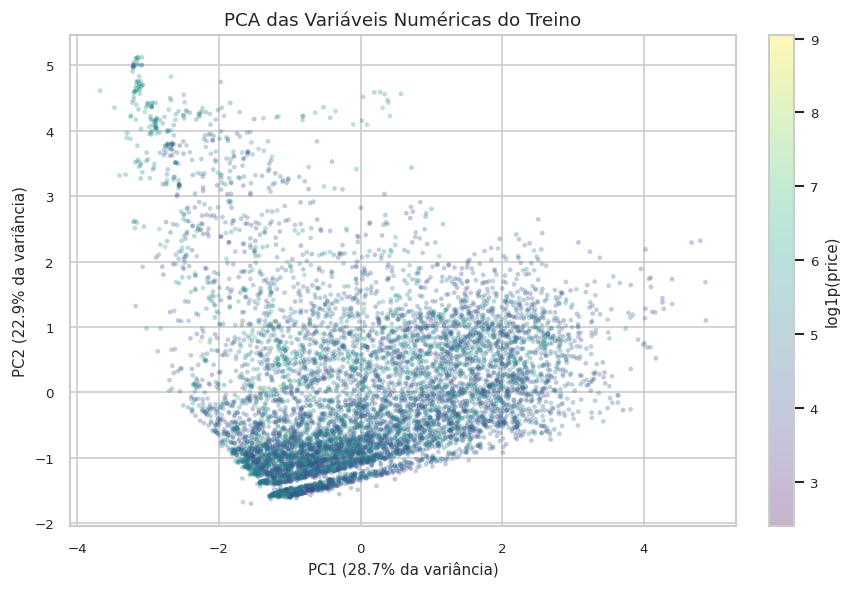

In [22]:
num_all = skewed_num + review_num + other_num

pca_preprocessor = ColumnTransformer([
    ("skewed", skewed_pipeline, skewed_num),
    ("review", review_pipeline, review_num),
    ("other", other_num_pipeline, other_num),
])
X_train_num_scaled = pca_preprocessor.fit_transform(X_train)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_train_num_scaled)

rng = np.random.default_rng(42)
sample_idx = rng.choice(len(pca_result), size=min(8000, len(pca_result)), replace=False)
plt.figure(figsize=(7, 4.8), constrained_layout=True)
scatter = plt.scatter(pca_result[sample_idx, 0], pca_result[sample_idx, 1],
                      c=np.log1p(y_train.iloc[sample_idx]), cmap="viridis",
                      alpha=0.30, s=8, linewidths=0)
plt.colorbar(scatter, label="log1p(price)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% da variância)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% da variância)")
plt.title("PCA das Variáveis Numéricas do Treino")
plt.show()

print("Variância explicada por componente:", pca.explained_variance_ratio_)
print("Variância explicada acumulada:", pca.explained_variance_ratio_.sum())
loadings = pd.DataFrame(pca.components_.T, columns=["PC1", "PC2"], index=num_all)
display(loadings.style.format("{:.3f}"))

# 4.6 Interpretação do PCA

O **PC1**, responsável por aproximadamente **28,7%** da variância, é formado principalmente por `reviews_per_month` (0,629) e `number_of_reviews` (0,611), em oposição parcial a `minimum_nights` (-0,385). Ele pode ser interpretado como um eixo relacionado à atividade de avaliações dos anúncios.

O **PC2**, com aproximadamente **22,9%**, é dominado por `availability_365` (0,633) e `calculated_host_listings_count` (0,619), sugerindo um eixo associado à disponibilidade e à atuação de anfitriões com vários anúncios. Juntos, os componentes preservam cerca de **51,5%** da variância numérica.

O gráfico não revela grupos de preço claramente separados: a cor varia gradualmente e existe grande sobreposição, como esperado para um target contínuo. As cargas explicam a estrutura das variáveis, mas **não representam diretamente importância preditiva para o preço**. Como dois componentes descartariam quase metade da variância numérica, o PCA não será incluído automaticamente no pipeline da APS2.

# 4.7 Pipeline de pré-processamento para a APS2

As decisões anteriores são reunidas em `Pipeline` e `ColumnTransformer`. Cada grupo de colunas recebe seu tratamento específico. O ajuste (`fit_transform`) ocorre somente no treino; o teste recebe apenas `transform`, evitando vazamento.

O PCA não entra no pipeline final pelos motivos discutidos no item 4.6. O resultado é uma matriz numérica pronta para ser conectada a um regressor na APS2, mas nenhum modelo é treinado nesta entrega.

In [23]:
preprocessor = ColumnTransformer([
    ("skewed", skewed_pipeline, skewed_num),
    ("review", review_pipeline, review_num),
    ("other_num", other_num_pipeline, other_num),
    ("cat", categorical_pipeline, cat_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Shape treino processado:", X_train_processed.shape)
print("Shape teste processado:", X_test_processed.shape)
print("Mesmo número de colunas:", X_train_processed.shape[1] == X_test_processed.shape[1])
print("Valores não finitos no treino:", int((~np.isfinite(X_train_processed)).sum()))
print("Valores não finitos no teste:", int((~np.isfinite(X_test_processed)).sum()))

Shape treino processado: (39107, 139)
Shape teste processado: (9777, 139)
Mesmo número de colunas: True
Valores não finitos no treino: 0
Valores não finitos no teste: 0


# 5. Relatório final da EDA

## Principais achados

1. O dataset possui 48.895 anúncios e 16 colunas. O alvo futuro é o preço por noite.
2. Há 11 preços iguais a zero, tratados como inconsistência. Não foram encontrados IDs duplicados.
3. As ausências de `reviews_per_month` representam anúncios sem avaliações; por isso a imputação escolhida é zero.
4. Preço e variáveis de contagem apresentam caudas longas. Valores extremos plausíveis serão preservados e comprimidos por transformação logarítmica quando apropriado.
5. Tipo de acomodação, borough e bairro possuem associações claras com preço, enquanto variáveis numéricas isoladas apresentam correlações fracas com o target.
6. Manhattan, Brooklyn, Entire home/apt e Private room dominam a amostra. Resultados para categorias minoritárias devem ser interpretados com cautela.
7. O PCA não revela agrupamentos bem separados e dois componentes não preservam toda a informação numérica, por isso não foi incluído no pipeline final.
8. O pipeline final realiza imputação, `log1p`, padronização e one-hot encoding sem aprender informações do teste.

## Limitações

Os dados são de 2019, representam preços anunciados — não reservas efetivamente realizadas — e não incluem comodidades, capacidade, sazonalidade ou qualidade das fotos. As relações observadas são associativas, não causais.

## Próxima etapa

Na APS2, o pipeline poderá ser conectado a um baseline e a modelos de regressão, avaliados com validação cruzada e métricas em dólares. O conjunto de teste aqui reservado deverá permanecer intocado até a avaliação final.

## Referências

- Kaggle. *New York City Airbnb Open Data*: https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data
- Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR, 12, 2825–2830.
- Documentação do scikit-learn: `Pipeline`, `ColumnTransformer`, `OneHotEncoder`, `StandardScaler` e `PCA`.
